In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

In [42]:
train = pd.read_csv('data/train.csv')

In [43]:
train.shape

(1460, 81)

In [44]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [45]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [46]:
train.duplicated().sum()

np.int64(0)

In [47]:
train.dtypes.value_counts()

str        43
int64      35
float64     3
Name: count, dtype: int64

In [48]:
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [49]:
missing_percent = (train.isnull().mean() * 100).sort_values(ascending=False)
missing_percent = missing_percent[missing_percent > 0]
missing_percent

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [50]:
none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType",
    "FireplaceQu", "GarageQual", "GarageType", "GarageFinish",
    "GarageCond", "BsmtFinType2", "BsmtExposure", "BsmtCond",
    "BsmtQual", "BsmtFinType1"
]
zero_cols = ["GarageYrBlt", "MasVnrArea"]


def fill_structural_na(df):
    df = df.copy()
    df[none_cols] = df[none_cols].fillna("None")
    df[zero_cols] = df[zero_cols].fillna(0)
    return df


train = fill_structural_na(train)

In [51]:
train.isnull().sum().sort_values(ascending=False)

LotFrontage      259
Electrical         1
Id                 0
MSZoning           0
MSSubClass         0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

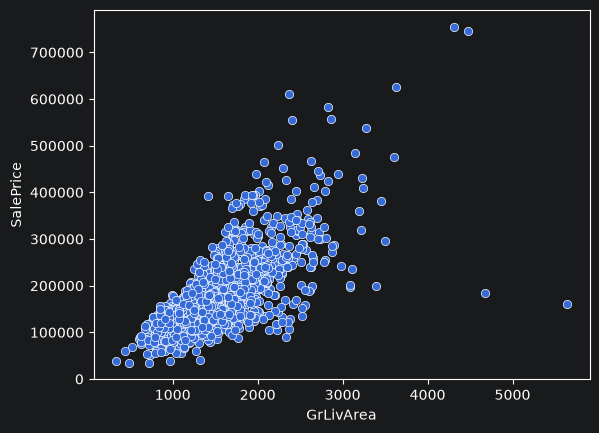

In [52]:
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice")
plt.show()

In [53]:
is_outlier = (train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)

print(f"Найдено выбросов: {is_outlier.sum()}")
train = train[~is_outlier].reset_index(drop=True)

Найдено выбросов: 2


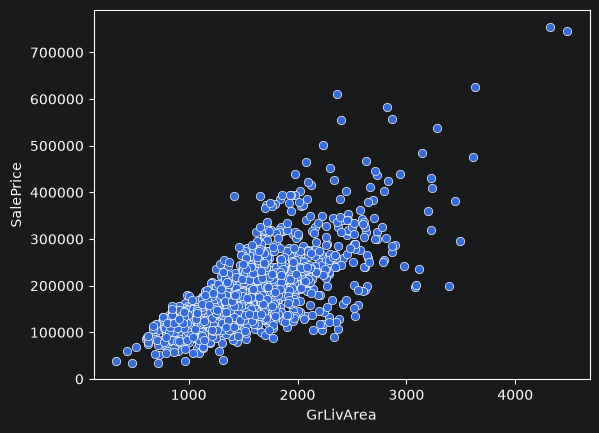

In [54]:
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice")
plt.show()

In [55]:
train["SalePrice"] = np.log1p(train["SalePrice"])

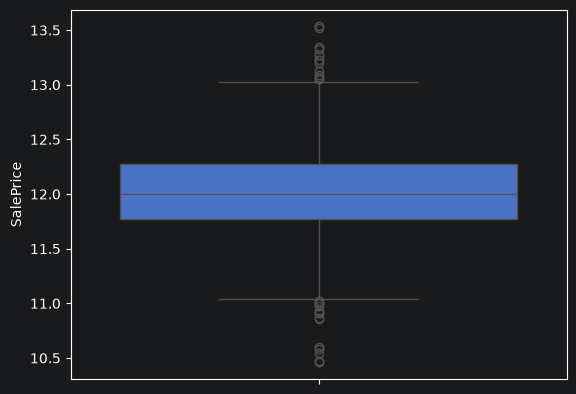

In [56]:
sns.boxplot(y=train["SalePrice"])
plt.show()

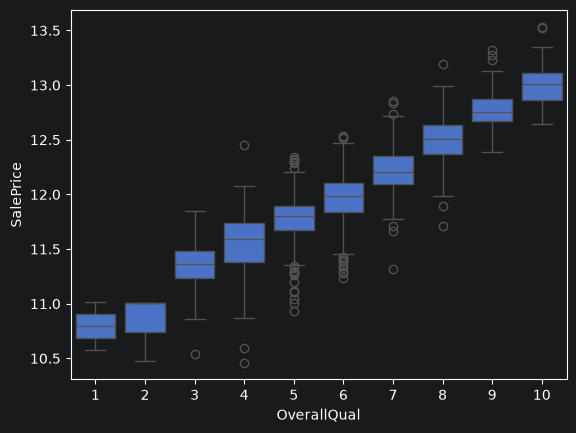

In [57]:
sns.boxplot(data=train, x="OverallQual", y="SalePrice")
plt.show()

In [58]:
num_cols_all = train.select_dtypes(include=["int64", "float64"]).columns
corr = train[num_cols_all].corr()
corr_saleprice = corr["SalePrice"].sort_values(ascending=False)
corr_saleprice

SalePrice        1.000000
OverallQual      0.821405
GrLivArea        0.725211
GarageCars       0.681033
GarageArea       0.656129
TotalBsmtSF      0.647563
1stFlrSF         0.620500
FullBath         0.595899
YearBuilt        0.587043
YearRemodAdd     0.565992
TotRmsAbvGrd     0.537702
Fireplaces       0.491998
MasVnrArea       0.430570
BsmtFinSF1       0.392283
LotFrontage      0.372900
GarageYrBlt      0.349013
WoodDeckSF       0.334251
OpenPorchSF      0.325215
2ndFlrSF         0.319953
HalfBath         0.314186
LotArea          0.260544
BsmtFullBath     0.237099
BsmtUnfSF        0.221892
BedroomAbvGr     0.209035
ScreenPorch      0.121245
PoolArea         0.074338
MoSold           0.057064
3SsnPorch        0.054914
BsmtFinSF2       0.004863
BsmtHalfBath    -0.005124
Id              -0.017774
MiscVal         -0.020012
OverallCond     -0.036821
YrSold          -0.037151
LowQualFinSF    -0.037951
MSSubClass      -0.073969
KitchenAbvGr    -0.147534
EnclosedPorch   -0.149029
Name: SalePr

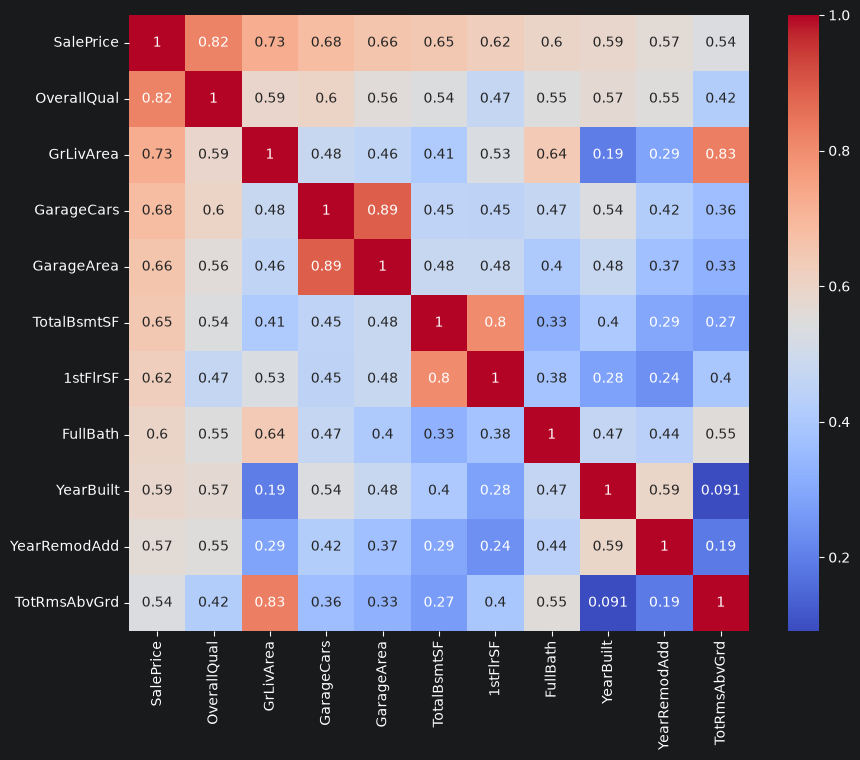

In [59]:
top_features = corr_saleprice.abs().sort_values(ascending=False).head(11).index

plt.figure(figsize=(10, 8))
sns.heatmap(train[top_features].corr(), annot=True, cmap="coolwarm")
plt.show()

In [60]:
X = train.drop(columns=["SalePrice", "Id"])
y = train["SalePrice"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "str"]).columns

In [61]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [64]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10))
])
baseline_pipeline.fit(X_train, y_train)
baseline_rmse = root_mean_squared_error(
    y_val, baseline_pipeline.predict(X_val)
)
print(f"Baseline (Ridge) RMSE, log scale, один split: {baseline_rmse:.4f}")

Baseline (Ridge) RMSE, log scale, один split: 0.1230


In [69]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=10),
    "Lasso": Lasso(alpha=0.001),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor(n_estimators=1000, learning_rate=0.05, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42, verbosity=-1),
}

cv_results = []
for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_results.append({
        "model": name,
        "rmse_mean": -scores.mean(),
        "rmse_std": scores.std(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("rmse_mean").reset_index(drop=True)
cv_results_df

,model,rmse_mean,rmse_std
0,ElasticNet,0.111943,0.006196
1,Lasso,0.112771,0.005769
2,Ridge,0.115136,0.006288
3,LinearRegression,0.127013,0.010816
4,LightGBM,0.127087,0.008247
5,XGBoost,0.127362,0.008453
6,KNN,0.170863,0.004726


In [70]:
ridge_pipeline = Pipeline([("preprocessor", preprocessor), ("model", Ridge())])
ridge_param_grid = {"model__alpha": [0.1, 1, 3, 5, 10, 20, 30, 50, 100]}

ridge_search = GridSearchCV(
    ridge_pipeline, ridge_param_grid, cv=5, scoring="neg_root_mean_squared_error"
)
ridge_search.fit(X, y)
print("Ridge best params:", ridge_search.best_params_)
print("Ridge best RMSE:", -ridge_search.best_score_)

Ridge best params: {'model__alpha': 20}
Ridge best RMSE: 0.11496045498196772


In [72]:
lasso_pipeline = Pipeline([("preprocessor", preprocessor), ("model", Lasso(max_iter=10000))])
lasso_param_grid = {"model__alpha": [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05]}

lasso_search = GridSearchCV(
    lasso_pipeline, lasso_param_grid, cv=5, scoring="neg_root_mean_squared_error"
)
lasso_search.fit(X, y)
print("Lasso best params:", lasso_search.best_params_)
print("Lasso best RMSE:", -lasso_search.best_score_)

Lasso best params: {'model__alpha': 0.0005}
Lasso best RMSE: 0.11176990866149798


In [77]:
elasticnet_pipeline = Pipeline([("preprocessor", preprocessor), ("model", ElasticNet(max_iter=10000))])
elasticnet_param_grid = {
    "model__alpha": [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
}

elasticnet_search = GridSearchCV(
    elasticnet_pipeline, elasticnet_param_grid, cv=5, scoring="neg_root_mean_squared_error"
)
elasticnet_search.fit(X, y)
print("ElasticNet best params:", elasticnet_search.best_params_)
print("ElasticNet best RMSE:", -elasticnet_search.best_score_)

ElasticNet best params: {'model__alpha': 0.0005, 'model__l1_ratio': 0.9}
ElasticNet best RMSE: 0.11190464556252133


In [73]:
knn_pipeline = Pipeline([("preprocessor", preprocessor), ("model", KNeighborsRegressor())])
knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 10, 15, 20],
    "model__weights": ["uniform", "distance"],
}

knn_search = GridSearchCV(
    knn_pipeline, knn_param_grid, cv=5, scoring="neg_root_mean_squared_error"
)
knn_search.fit(X, y)
print("KNN best params:", knn_search.best_params_)
print("KNN best RMSE:", -knn_search.best_score_)

KNN best params: {'model__n_neighbors': 7, 'model__weights': 'distance'}
KNN best RMSE: 0.16924363344642152


In [74]:
lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(random_state=42)),
])
lgbm_param_dist = {
    "model__n_estimators": [300, 500, 800, 1000, 1500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__num_leaves": [15, 31, 63, 127],
    "model__max_depth": [-1, 5, 8, 12],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
}

lgbm_search = RandomizedSearchCV(
    lgbm_pipeline,
    param_distributions=lgbm_param_dist,
    n_iter=30,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
)
lgbm_search.fit(X, y)
print("LightGBM best params:", lgbm_search.best_params_)
print("LightGBM best RMSE:", -lgbm_search.best_score_)

LightGBM best params: {'model__subsample': 0.8, 'model__num_leaves': 63, 'model__n_estimators': 800, 'model__max_depth': 5, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.6}
LightGBM best RMSE: 0.1201385943806144


In [75]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42)),
])
xgb_param_dist = {
    "model__n_estimators": [300, 500, 800, 1000, 1500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
)
xgb_search.fit(X, y)
print("XGBoost best params:", xgb_search.best_params_)
print("XGBoost best RMSE:", -xgb_search.best_score_)

XGBoost best params: {'model__subsample': 0.8, 'model__n_estimators': 1500, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}
XGBoost best RMSE: 0.11495283642237766


In [78]:
tuned_results = pd.DataFrame([
    {"model": "Ridge (tuned)", "rmse": -ridge_search.best_score_},
    {"model": "Lasso (tuned)", "rmse": -lasso_search.best_score_},
    {"model": "ElasticNet (tuned)", "rmse": -elasticnet_search.best_score_},
    {"model": "KNN (tuned)", "rmse": -knn_search.best_score_},
    {"model": "LightGBM (tuned)", "rmse": -lgbm_search.best_score_},
    {"model": "XGBoost (tuned)", "rmse": -xgb_search.best_score_},
]).sort_values("rmse").reset_index(drop=True)
tuned_results

,model,rmse
0,Lasso (tuned),0.111770
1,ElasticNet (tuned),0.111905
2,XGBoost (tuned),0.114953
3,Ridge (tuned),0.114960
4,LightGBM (tuned),0.120139
5,KNN (tuned),0.169244


In [82]:
final_pipeline = lasso_search.best_estimator_
final_pipeline.fit(X, y)

test = pd.read_csv("data/test.csv")
test = fill_structural_na(test)

test_ids = test["Id"]
X_test = test.drop(columns=["Id"])

test_preds_log = final_pipeline.predict(X_test)
test_preds = np.expm1(test_preds_log)

submission = pd.DataFrame({"Id": test_ids, "SalePrice": test_preds})
submission.to_csv("submission.csv", index=False)